# Question 3: Robustness Evaluation on Noisy Conditions

This notebook evaluates two AASIST checkpoints on noisy-only conditions.

Evaluation plan enforced in code:
- 6 noisy conditions
- 100 files per condition (50 real + 50 spoof)
- 600 files per model
- 12 evaluation sets total (6 conditions x 2 models)

Metrics reported per condition and per model:
- EER
- Confusion matrix (TN, FP, FN, TP)
- Bypass Rate (BR): spoof predicted as bonafide

Comparative analysis includes:
- EER vs SNR
- BR vs SNR

Expected data layout:
- Real noisy: `data/audio/real/speaker_1_<noise>_<snr>dB` and `data/audio/real/speaker_2_<noise>_<snr>dB`
- Fake noisy: `data/audio/synthetic/speaker1_<noise>_<snr>dB` and `data/audio/synthetic/speaker2_<noise>_<snr>dB`

In [1]:
import math
import re
from dataclasses import dataclass, field
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, roc_curve

sns.set_style('whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


/DATA/teaching/conda_cache/envs/don/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
ROOT = Path('/DATA/Trashaimpms/ekansh')
REAL_ROOT = ROOT / 'data' / 'audio' / 'real'
FAKE_ROOT = ROOT / 'data' / 'audio' / 'synthetic'

MODEL_CANDIDATES = {
    'ModelA': [ROOT / 'ModelA_PA_bestnew.pt', ROOT / 'ModelA_LA_bestnew.pt'],
    'ModelB': [ROOT / 'ModelB_PA_bestnew.pt'],
}
THRESHOLDS = {
    'ModelA': 0.420,
    'ModelB': 0.118,
}

# Required evaluation scope from Question 3
EVAL_REAL_PER_COND = 50
EVAL_FAKE_PER_COND = 50
EVAL_PER_COND = EVAL_REAL_PER_COND + EVAL_FAKE_PER_COND

def resolve_model_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'None of the model candidates exist: {candidates}')

MODEL_PATHS = {name: resolve_model_path(paths) for name, paths in MODEL_CANDIDATES.items()}

real_speaker_cond_dirs = {'speaker_1': {}, 'speaker_2': {}}
for spk in ['speaker_1', 'speaker_2']:
    for d in REAL_ROOT.glob(f'{spk}_*'):
        if not d.is_dir():
            continue
        cond = d.name[len(spk) + 1:]
        real_speaker_cond_dirs[spk][cond] = d

fake_speaker_cond_dirs = {'speaker1': {}, 'speaker2': {}}
for spk in ['speaker1', 'speaker2']:
    for d in FAKE_ROOT.glob(f'{spk}_*'):
        if not d.is_dir():
            continue
        cond = d.name[len(spk) + 1:]
        fake_speaker_cond_dirs[spk][cond] = d

conditions = sorted(
    set(real_speaker_cond_dirs['speaker_1']) & 
    set(real_speaker_cond_dirs['speaker_2']) & 
    set(fake_speaker_cond_dirs['speaker1']) & 
    set(fake_speaker_cond_dirs['speaker2'])
)

def parse_condition(cond):
    import re
    m = re.match(r'([A-Za-z]+)_(\d+)dB$', cond)
    if m:
        return m.group(1).lower(), int(m.group(2))
    return cond, -1

conditions = sorted(conditions, key=lambda c: (parse_condition(c)[0], parse_condition(c)[1]))

assert len(conditions) == 6, f'Expected 6 noisy conditions, found {len(conditions)}: {conditions}'

# Verify each condition has enough files for 50 real + 50 spoof selection
for cond in conditions:
    n_real = len(list(real_speaker_cond_dirs['speaker_1'][cond].glob('*.wav'))) + len(list(real_speaker_cond_dirs['speaker_2'][cond].glob('*.wav')))
    n_fake = len(list(fake_speaker_cond_dirs['speaker1'][cond].glob('*.wav'))) + len(list(fake_speaker_cond_dirs['speaker2'][cond].glob('*.wav')))
    assert n_real >= EVAL_REAL_PER_COND, f'{cond}: need at least {EVAL_REAL_PER_COND} real files, found {n_real}'
    assert n_fake >= EVAL_FAKE_PER_COND, f'{cond}: need at least {EVAL_FAKE_PER_COND} spoof files, found {n_fake}'

EXPECTED_PER_MODEL = len(conditions) * EVAL_PER_COND
EXPECTED_EVAL_SETS = len(conditions) * len(MODEL_PATHS)

print('Using conditions:', conditions)
print('Resolved models:')
for k, v in MODEL_PATHS.items():
    print(f'  {k}: {v.name}')
print(f'Per condition: {EVAL_PER_COND} files ({EVAL_REAL_PER_COND} real + {EVAL_FAKE_PER_COND} spoof)')
print(f'Expected per model: {EXPECTED_PER_MODEL} files')
print(f'Expected total evaluation sets: {EXPECTED_EVAL_SETS}')

baseline_csv = ROOT / 'reports' / 'question2_part2_attack_metrics_summary.csv'
import pandas as pd
baseline_df = pd.read_csv(baseline_csv) if baseline_csv.exists() else pd.DataFrame()
if not baseline_df.empty:
    print('Loaded baseline from Task 2 summary (not re-evaluated in this notebook):')
    display(baseline_df[['model', 'eer', 'f1_spoof', 'attack_success_rate', 'tn', 'fp', 'fn', 'tp']])
else:
    print('Baseline summary CSV not found; continuing with noisy-only evaluation.')

Using conditions: ['awgn_5dB', 'awgn_10dB', 'awgn_20dB', 'babble_5dB', 'babble_10dB', 'babble_20dB']
Resolved models:
  ModelA: ModelA_LA_bestnew.pt
  ModelB: ModelB_PA_bestnew.pt
Per condition: 100 files (50 real + 50 spoof)
Expected per model: 600 files
Expected total evaluation sets: 12
Loaded baseline from Task 2 summary (not re-evaluated in this notebook):


,model,eer,f1_spoof,attack_success_rate,tn,fp,fn,tp
0,ModelA,0.20,0.714286,0.40,46,4,20,30
1,ModelB,0.52,0.400000,0.64,28,22,32,18


In [4]:
@dataclass
class Config:
    sample_rate: int = 16000
    sinc_kernel: int = 1024
    nb_samp: int = 64600
    filts: list = field(default_factory=lambda: [70, [70, 32], [32, 32], [32, 64], [64, 64]])
    nb_fc_node: int = 64
    gat_dims: list = field(default_factory=lambda: [64, 32])
    temperatures: list = field(default_factory=lambda: [2.0, 2.0, 100.0, 100.0])

CFG = Config()

class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * math.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)

    def __init__(self, out_channels, kernel_size, sr=16000, min_low_hz=50, min_band_hz=50):
        super().__init__()
        if kernel_size % 2 == 0:
            kernel_size += 1
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sr
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        low_hz = 30.0
        high_hz = sr / 2 - (min_low_hz + min_band_hz)
        mel = torch.linspace(self.to_mel(low_hz), self.to_mel(high_hz), out_channels + 1)
        hz = torch.tensor([self.to_hz(float(m)) for m in mel], dtype=torch.float32)
        self.low_hz_ = nn.Parameter(hz[:-1].view(-1, 1))
        self.band_hz_ = nn.Parameter((hz[1:] - hz[:-1]).view(-1, 1))

        n_lin = torch.linspace(0, kernel_size / 2 - 1, kernel_size // 2)
        self.register_buffer('window_', 0.54 - 0.46 * torch.cos(2 * math.pi * n_lin / kernel_size))
        n = (kernel_size - 1) / 2.0
        self.register_buffer('n_', 2 * math.pi * torch.arange(-n, 0).view(1, -1) / sr)

    def forward(self, x):
        low = self.min_low_hz + torch.abs(self.low_hz_)
        high = torch.clamp(low + self.min_band_hz + torch.abs(self.band_hz_), self.min_low_hz, self.sample_rate / 2)
        band = (high - low)[:, 0]
        f_l = torch.matmul(low, self.n_)
        f_h = torch.matmul(high, self.n_)
        bp_l = ((torch.sin(f_h) - torch.sin(f_l)) / (self.n_ / 2)) * self.window_
        bp = torch.cat([bp_l, 2 * band.view(-1, 1), torch.flip(bp_l, [1])], 1)
        bp = bp / (2 * band[:, None])
        return F.conv1d(x, bp.view(self.out_channels, 1, self.kernel_size), padding=self.kernel_size // 2)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, first=False):
        super().__init__()
        self.first = first
        self.lrelu = nn.LeakyReLU(0.3)
        if not first:
            self.bn1 = nn.BatchNorm1d(in_ch)
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = x if self.first else self.lrelu(self.bn1(x))
        return self.conv2(self.lrelu(self.bn2(self.conv1(out)))) + identity

class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, K=4):
        super().__init__()
        self.K = K
        self.proj = nn.Linear(in_dim, out_dim, bias=False)
        self.attn = nn.Linear(2 * out_dim, 1, bias=False)
        self.lrelu = nn.LeakyReLU(0.2)

    def forward(self, x):
        B, N, _ = x.shape
        h = self.proj(x)
        e = self.lrelu(self.attn(torch.cat([h.unsqueeze(2).expand(-1, -1, N, -1), h.unsqueeze(1).expand(-1, N, -1, -1)], -1)).squeeze(-1))
        if self.K < N:
            thr = torch.topk(e, min(self.K, N), -1).values[..., -1:]
            e = e.masked_fill(e < thr, float('-inf'))
        return F.elu(torch.bmm(F.softmax(e, -1), h)), None

class HSGAL(nn.Module):
    def __init__(self, dim_s, dim_t, gat_dims, K=4, temperature=2.0):
        super().__init__()
        self.gat_s = GraphAttentionLayer(dim_s, gat_dims[0], K)
        self.gat_t = GraphAttentionLayer(dim_t, gat_dims[0], K)
        self.cross = nn.Linear(gat_dims[0], gat_dims[1])
        self.temp = temperature

    def _attend(self, query_src, key_src):
        q = self.cross(query_src.mean(1, keepdim=True))
        k = self.cross(key_src)
        a = F.softmax(torch.bmm(q, k.transpose(1, 2)) / self.temp, -1)
        return torch.bmm(a, k).squeeze(1)

    def forward(self, xs, xt):
        hs, _ = self.gat_s(xs)
        ht, _ = self.gat_t(xt)
        return torch.cat([self._attend(hs, ht), self._attend(ht, hs)], 1)

class AASIST(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.sinc = SincConv(70, cfg.sinc_kernel, sr=cfg.sample_rate)
        self.bn0 = nn.BatchNorm1d(70)
        self.pool0 = nn.MaxPool1d(3)
        self.drop0 = nn.Dropout(0.05)
        self.enc_blocks = nn.ModuleList()
        self.enc_pools = nn.ModuleList()
        for i, flt in enumerate(cfg.filts[1:]):
            self.enc_blocks.append(ResBlock(flt[0], flt[1], first=(i == 0)))
            self.enc_pools.append(nn.MaxPool1d(3))
        self.block_last = ResBlock(64, 64)
        self.bn_last = nn.BatchNorm1d(64)
        self.drop_last = nn.Dropout(0.05)
        self.hsgal = HSGAL(64, 64, cfg.gat_dims, K=4, temperature=cfg.temperatures[0])
        self.fc1 = nn.Linear(2 * cfg.gat_dims[1], cfg.nb_fc_node)
        self.bn_fc = nn.BatchNorm1d(cfg.nb_fc_node)
        self.fc2 = nn.Linear(cfg.nb_fc_node, 2)

    def forward(self, x):
        out = F.leaky_relu(self.bn0(torch.abs(self.sinc(x))), 0.3)
        out = self.drop0(self.pool0(out))
        for blk, pool in zip(self.enc_blocks, self.enc_pools):
            out = pool(blk(out))
        out = self.drop_last(F.leaky_relu(self.bn_last(self.block_last(out)), 0.3))
        xs = out.permute(0, 2, 1)
        h = F.leaky_relu(self.bn_fc(self.fc1(self.hsgal(xs, xs))), 0.3)
        return self.fc2(h)

print('AASIST class loaded.')

AASIST class loaded.


In [5]:
def load_waveform(path: Path, sr: int = 16000) -> np.ndarray:
    wave, orig_sr = sf.read(str(path), always_2d=False)
    if isinstance(wave, np.ndarray) and wave.ndim == 2:
        wave = wave.mean(axis=1)
    wave = np.asarray(wave, dtype=np.float32)
    if orig_sr != sr:
        wave = librosa.resample(wave, orig_sr=orig_sr, target_sr=sr).astype(np.float32)
    return wave

def pre_emphasis_filter(wave: np.ndarray, coef: float = 0.97) -> np.ndarray:
    if len(wave) < 2:
        return wave
    return np.append(wave[0], wave[1:] - coef * wave[:-1]).astype(np.float32)

def energy_vad(wave: np.ndarray, sr: int = 16000, frame_ms: int = 25, hop_ms: int = 10, threshold_db: float = -40.0) -> np.ndarray:
    frame_len = int(sr * frame_ms / 1000)
    hop_len = int(sr * hop_ms / 1000)
    if len(wave) < frame_len:
        return wave
    frames = librosa.util.frame(wave, frame_length=frame_len, hop_length=hop_len)
    energy = 20 * np.log10(np.sqrt(np.mean(frames**2, axis=0)) + 1e-9)
    voiced = energy > energy.max() + threshold_db
    if not voiced.any():
        return wave
    first = voiced.argmax() * hop_len
    last = (len(voiced) - voiced[::-1].argmax()) * hop_len
    return wave[first:last]

def rms_normalise(wave: np.ndarray, target_db: float = -23.0) -> np.ndarray:
    rms = np.sqrt(np.mean(wave**2) + 1e-9)
    return (wave * (10 ** (target_db / 20) / rms)).astype(np.float32)

def pad_or_crop(wave: np.ndarray, n_samples: int = 64600) -> np.ndarray:
    if len(wave) >= n_samples:
        start = (len(wave) - n_samples) // 2
        return wave[start:start+n_samples].astype(np.float32)
    rep = n_samples // max(1, len(wave)) + 1
    return np.tile(wave, rep)[:n_samples].astype(np.float32)

def preprocess_for_aasist(path: Path) -> torch.Tensor:
    wave = load_waveform(path, sr=CFG.sample_rate)
    wave = pre_emphasis_filter(wave, coef=0.97)
    wave = energy_vad(wave, sr=CFG.sample_rate)
    wave = rms_normalise(wave)
    wave = pad_or_crop(wave, n_samples=CFG.nb_samp)
    return torch.from_numpy(wave).unsqueeze(0)

def compute_eer(labels: np.ndarray, scores: np.ndarray) -> float:
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1.0 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[i] + fnr[i]) / 2.0)

In [6]:
def numeric_key(path_obj):
    try:
        return int(path_obj.stem)
    except Exception:
        return path_obj.stem

all_metrics = []
all_preds = []

for model_name, ckpt_path in MODEL_PATHS.items():
    print(f'\nEvaluating {model_name} -> {ckpt_path.name}')
    model = AASIST(CFG).to(DEVICE)
    state = torch.load(str(ckpt_path), map_location='cpu', weights_only=False)
    model.load_state_dict(state, strict=True)
    model.eval()

    for cond in conditions:
        noise_type, snr_db = parse_condition(cond)

        real_files_all = sorted(real_fake_speaker_cond_dirs['speaker_1'][cond].glob('*.wav'), key=numeric_key)
        real_files_all += sorted(real_fake_speaker_cond_dirs['speaker_2'][cond].glob('*.wav'), key=numeric_key)
        fake_files_all = sorted(fake_speaker_cond_dirs['speaker1'][cond].glob('*.wav'), key=numeric_key)
        fake_files_all += sorted(fake_speaker_cond_dirs['speaker2'][cond].glob('*.wav'), key=numeric_key)

        if len(real_files_all) < EVAL_REAL_PER_COND:
            raise RuntimeError(f'{cond}: real files {len(real_files_all)} < required {EVAL_REAL_PER_COND}')
        if len(fake_files_all) < EVAL_FAKE_PER_COND:
            raise RuntimeError(f'{cond}: spoof files {len(fake_files_all)} < required {EVAL_FAKE_PER_COND}')

        real_files = real_files_all[:EVAL_REAL_PER_COND]
        fake_files = fake_files_all[:EVAL_FAKE_PER_COND]

        rows = []
        for p in real_files:
            rows.append({'path': p, 'label': 0, 'subset': 'real'})
        for p in fake_files:
            rows.append({'path': p, 'label': 1, 'subset': 'spoof'})

        eval_df = pd.DataFrame(rows)
        if len(eval_df) != EVAL_PER_COND:
            raise RuntimeError(f'{cond}: expected {EVAL_PER_COND} rows, got {len(eval_df)}')

        scores, labels, paths = [], [], []
        with torch.no_grad():
            for _, row in eval_df.iterrows():
                x = preprocess_for_aasist(row['path']).unsqueeze(0).to(DEVICE)
                logits = model(x)
                score = F.softmax(logits, dim=1)[0, 1].item()
                scores.append(float(score))
                labels.append(int(row['label']))
                paths.append(str(row['path']))

        scores = np.array(scores, dtype=np.float32)
        labels = np.array(labels, dtype=np.int64)
        thr = THRESHOLDS[model_name]
        preds = (scores >= thr).astype(int)

        cm = confusion_matrix(labels, preds, labels=[0, 1])
        tn, fp, fn, tp = map(int, cm.ravel())
        eer = compute_eer(labels, scores)

        spoof_count = int((labels == 1).sum())
        br = float(fn / max(1, spoof_count))

        all_metrics.append({
            'model': model_name,
            'checkpoint': str(ckpt_path),
            'condition': cond,
            'noise_type': noise_type,
            'snr_db': int(snr_db),
            'n_total': int(len(labels)),
            'n_real': int((labels == 0).sum()),
            'n_spoof': spoof_count,
            'threshold': float(thr),
            'eer': float(eer),
            'bypass_rate': br,
            'tn': tn,
            'fp': fp,
            'fn': fn,
            'tp': tp,
        })

        for p, y, s, pr in zip(paths, labels, scores, preds):
            all_preds.append({
                'model': model_name,
                'condition': cond,
                'noise_type': noise_type,
                'snr_db': int(snr_db),
                'path': p,
                'label': int(y),
                'score': float(s),
                'pred': int(pr),
            })

        print(f'  {cond}: n={len(labels)}, EER={eer:.4f}, BR={br:.4f}')

metrics_df = pd.DataFrame(all_metrics).sort_values(['model', 'noise_type', 'snr_db']).reset_index(drop=True)
preds_df = pd.DataFrame(all_preds).sort_values(['model', 'condition', 'path']).reset_index(drop=True)

# Hard checks for requested scope: 6 sets/model, 12 sets total, 600 files/model
if len(metrics_df) != EXPECTED_EVAL_SETS:
    raise RuntimeError(f'Expected {EXPECTED_EVAL_SETS} evaluation sets, got {len(metrics_df)}')

totals = metrics_df.groupby('model', as_index=False)['n_total'].sum().rename(columns={'n_total': 'total_files_evaluated'})
for _, r in totals.iterrows():
    if int(r['total_files_evaluated']) != EXPECTED_PER_MODEL:
        raise RuntimeError(f"{r['model']}: expected {EXPECTED_PER_MODEL} files, got {int(r['total_files_evaluated'])}")

print('\nEvaluation scope checks passed.')
print(f'- Evaluation sets: {len(metrics_df)} (expected {EXPECTED_EVAL_SETS})')
print(f'- Files per model expected: {EXPECTED_PER_MODEL}')
display(totals)
display(metrics_df)


Evaluating ModelA -> ModelA_LA_bestnew.pt
  awgn_5dB: n=100, EER=0.0000, BR=0.0000
  awgn_10dB: n=100, EER=0.0000, BR=0.0000
  awgn_20dB: n=100, EER=0.0000, BR=0.0000
  babble_5dB: n=100, EER=0.3900, BR=0.5600
  babble_10dB: n=100, EER=0.3500, BR=0.4600
  babble_20dB: n=100, EER=0.3100, BR=0.4200

Evaluating ModelB -> ModelB_PA_bestnew.pt
  awgn_5dB: n=100, EER=0.8200, BR=0.4200
  awgn_10dB: n=100, EER=0.8100, BR=0.8000
  awgn_20dB: n=100, EER=0.6200, BR=0.8200
  babble_5dB: n=100, EER=0.6000, BR=0.8000
  babble_10dB: n=100, EER=0.5900, BR=0.7600
  babble_20dB: n=100, EER=0.5600, BR=0.7000

Evaluation scope checks passed.
- Evaluation sets: 12 (expected 12)
- Files per model expected: 600


,model,total_files_evaluated
0,ModelA,600
1,ModelB,600


,model,checkpoint,condition,noise_type,snr_db,n_total,n_real,n_spoof,threshold,eer,bypass_rate,tn,fp,fn,tp
0,ModelA,/DATA/Trashaimpms/ekansh/ModelA_LA_bestnew.pt,awgn_5dB,awgn,5,100,50,50,0.420,0.00,0.00,41,9,0,50
1,ModelA,/DATA/Trashaimpms/ekansh/ModelA_LA_bestnew.pt,awgn_10dB,awgn,10,100,50,50,0.420,0.00,0.00,41,9,0,50
2,ModelA,/DATA/Trashaimpms/ekansh/ModelA_LA_bestnew.pt,awgn_20dB,awgn,20,100,50,50,0.420,0.00,0.00,42,8,0,50
3,ModelA,/DATA/Trashaimpms/ekansh/ModelA_LA_bestnew.pt,babble_5dB,babble,5,100,50,50,0.420,0.39,0.56,48,2,28,22
4,ModelA,/DATA/Trashaimpms/ekansh/ModelA_LA_bestnew.pt,babble_10dB,babble,10,100,50,50,0.420,0.35,0.46,48,2,23,27
5,ModelA,/DATA/Trashaimpms/ekansh/ModelA_LA_bestnew.pt,babble_20dB,babble,20,100,50,50,0.420,0.31,0.42,47,3,21,29
6,ModelB,/DATA/Trashaimpms/ekansh/ModelB_PA_bestnew.pt,awgn_5dB,awgn,5,100,50,50,0.118,0.82,0.42,1,49,21,29
7,ModelB,/DATA/Trashaimpms/ekansh/ModelB_PA_bestnew.pt,awgn_10dB,awgn,10,100,50,50,0.118,0.81,0.80,13,37,40,10
8,ModelB,/DATA/Trashaimpms/ekansh/ModelB_PA_bestnew.pt,awgn_20dB,awgn,20,100,50,50,0.118,0.62,0.82,26,24,41,9
9,ModelB,/DATA/Trashaimpms/ekansh/ModelB_PA_bestnew.pt,babble_5dB,babble,5,100,50,50,0.118,0.60,0.80,29,21,40,10


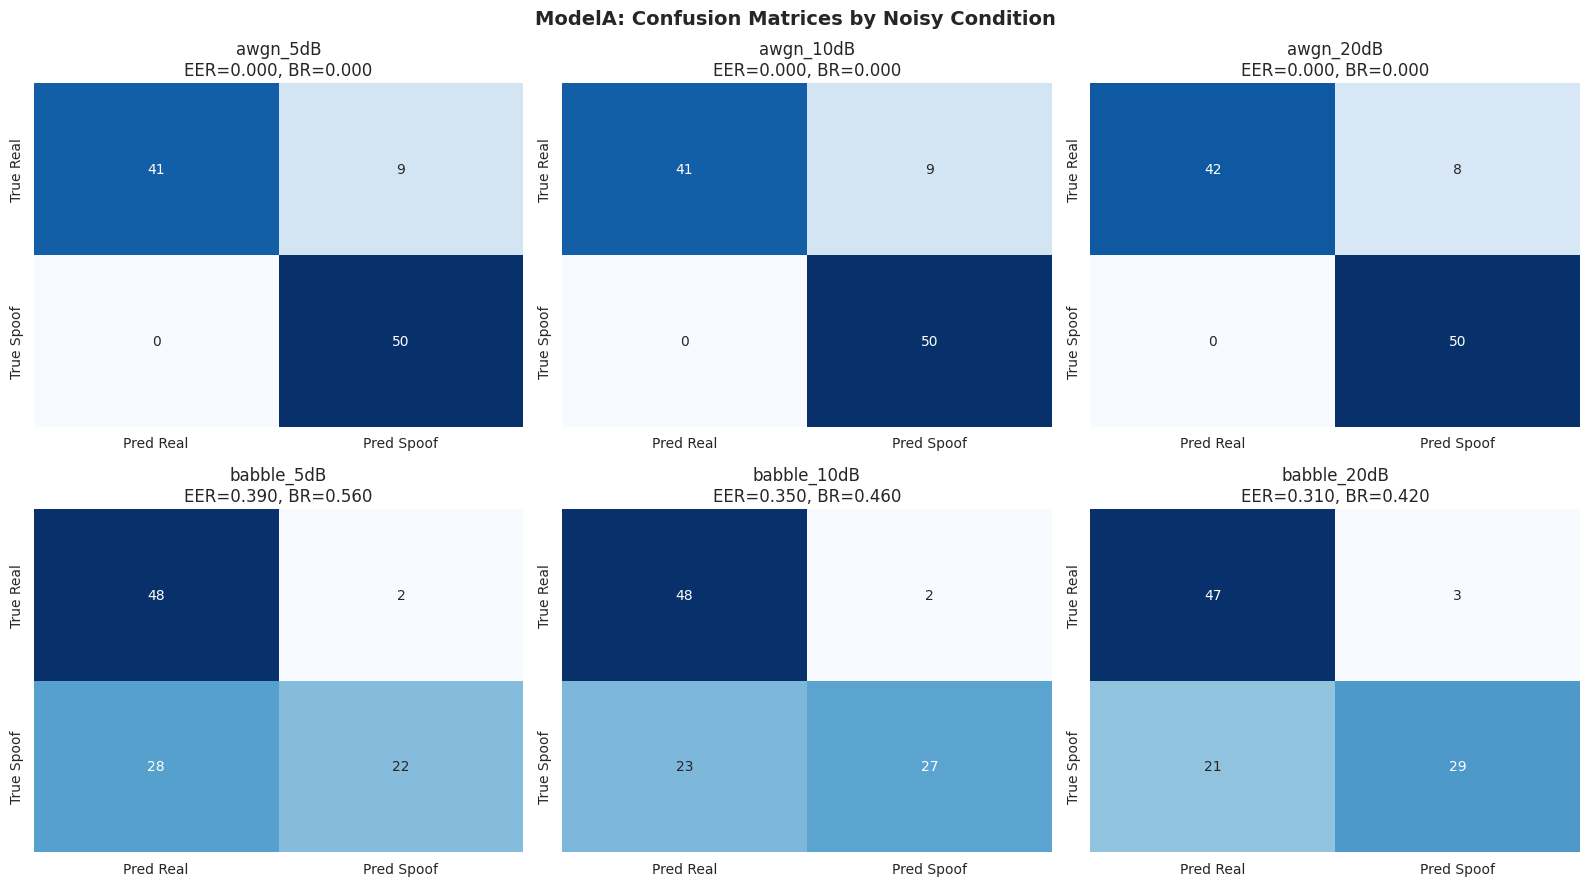

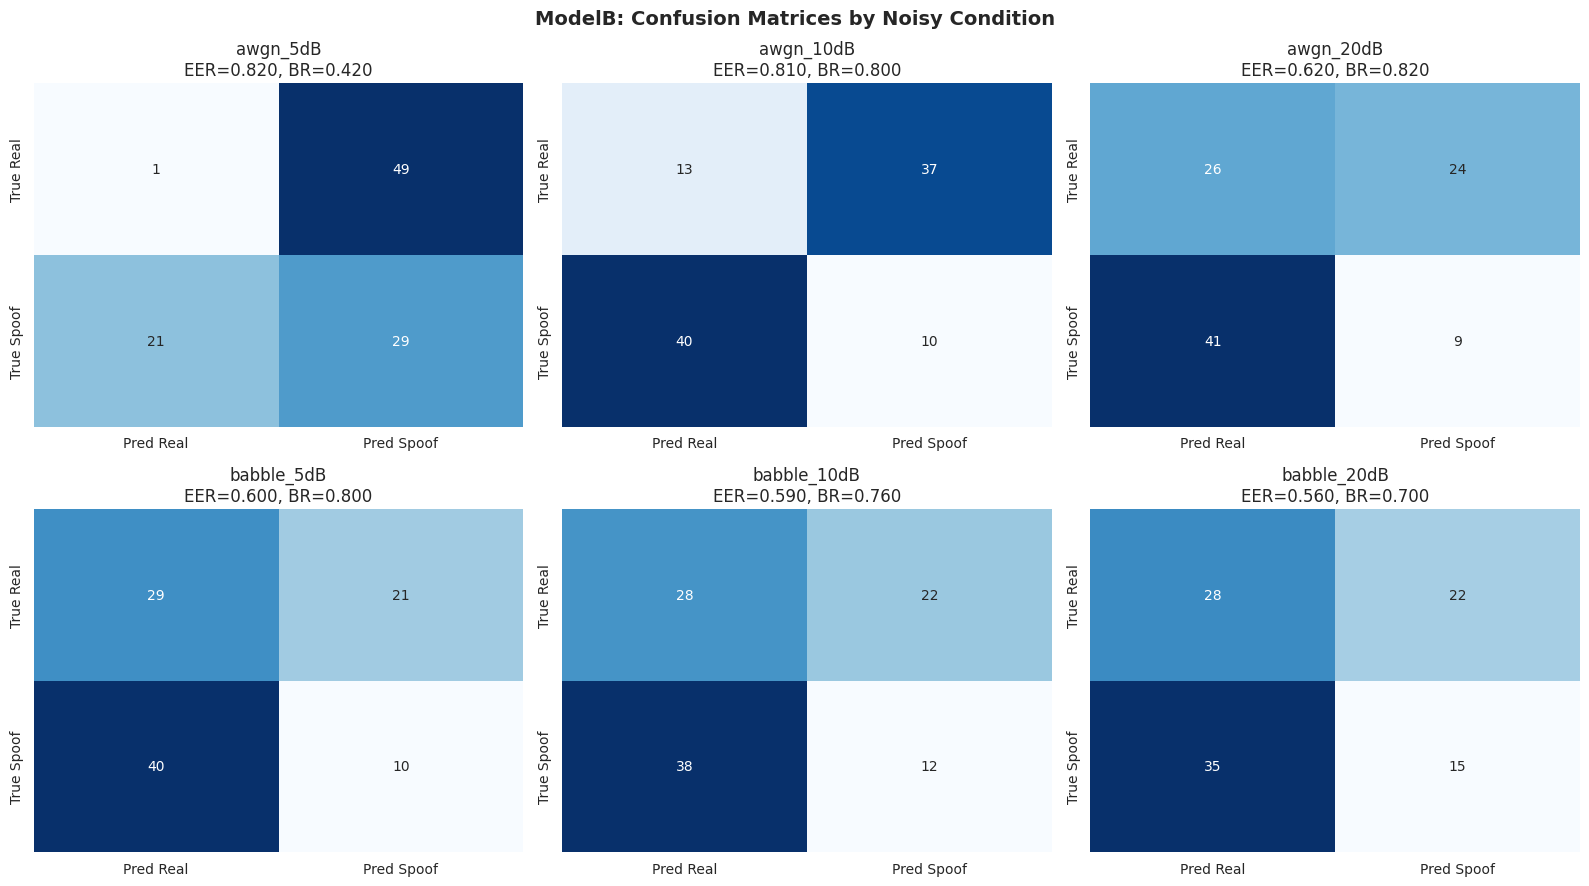

In [7]:
for model_name in metrics_df['model'].unique():
    sub = metrics_df[metrics_df['model'] == model_name].copy()
    sub = sub.sort_values(['noise_type', 'snr_db'])

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sub.iterrows()):
        cm = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]], dtype=int)
        annot = np.array([[f"{cm[0,0]}", f"{cm[0,1]}"], [f"{cm[1,0]}", f"{cm[1,1]}"]])
        sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False, ax=ax,
                    xticklabels=['Pred Real', 'Pred Spoof'],
                    yticklabels=['True Real', 'True Spoof'])
        ax.set_title(f"{row['condition']}\nEER={row['eer']:.3f}, BR={row['bypass_rate']:.3f}")

    for ax in axes[len(sub):]:
        ax.axis('off')

    plt.suptitle(f'{model_name}: Confusion Matrices by Noisy Condition', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

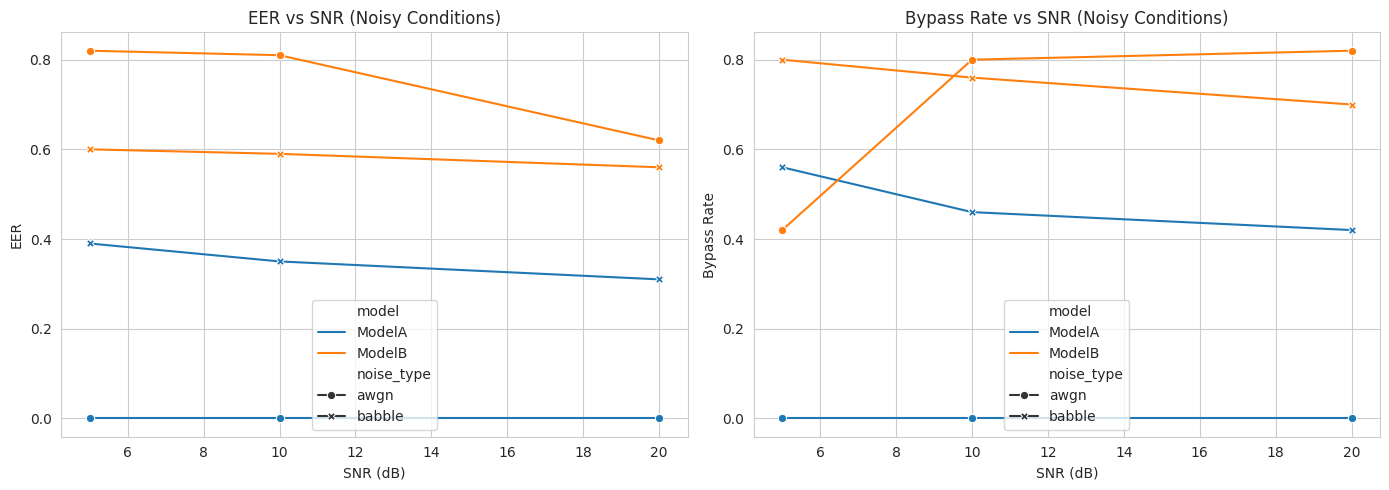

EER trend table:


model,noise_type,snr_db,ModelA,ModelB
0,awgn,5,0.00,0.82
1,awgn,10,0.00,0.81
2,awgn,20,0.00,0.62
3,babble,5,0.39,0.60
4,babble,10,0.35,0.59
5,babble,20,0.31,0.56


Bypass-rate trend table:


model,noise_type,snr_db,ModelA,ModelB
0,awgn,5,0.00,0.42
1,awgn,10,0.00,0.80
2,awgn,20,0.00,0.82
3,babble,5,0.56,0.80
4,babble,10,0.46,0.76
5,babble,20,0.42,0.70


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=metrics_df, x='snr_db', y='eer', hue='model', style='noise_type', markers=True, dashes=False, ax=axes[0])
axes[0].set_title('EER vs SNR (Noisy Conditions)')
axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('EER')

sns.lineplot(data=metrics_df, x='snr_db', y='bypass_rate', hue='model', style='noise_type', markers=True, dashes=False, ax=axes[1])
axes[1].set_title('Bypass Rate vs SNR (Noisy Conditions)')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('Bypass Rate')

plt.tight_layout()
plt.show()

pivot_eer = metrics_df.pivot_table(index=['noise_type', 'snr_db'], columns='model', values='eer', aggfunc='mean').reset_index()
pivot_br = metrics_df.pivot_table(index=['noise_type', 'snr_db'], columns='model', values='bypass_rate', aggfunc='mean').reset_index()

print('EER trend table:')
display(pivot_eer)
print('Bypass-rate trend table:')
display(pivot_br)

In [9]:
out_dir = ROOT / 'reports'
out_dir.mkdir(parents=True, exist_ok=True)

metrics_path = out_dir / 'question3_noisy_metrics.csv'
preds_path = out_dir / 'question3_noisy_per_file.csv'
eer_trend_path = out_dir / 'question3_eer_vs_snr.csv'
br_trend_path = out_dir / 'question3_br_vs_snr.csv'

metrics_df.to_csv(metrics_path, index=False)
preds_df.to_csv(preds_path, index=False)
pivot_eer.to_csv(eer_trend_path, index=False)
pivot_br.to_csv(br_trend_path, index=False)

if not baseline_df.empty:
    baseline_out = out_dir / 'question3_baseline_from_task2.csv'
    baseline_df.to_csv(baseline_out, index=False)

print('Saved files:')
print(metrics_path)
print(preds_path)
print(eer_trend_path)
print(br_trend_path)
if not baseline_df.empty:
    print(baseline_out)

Saved files:
/DATA/Trashaimpms/ekansh/reports/question3_noisy_metrics.csv
/DATA/Trashaimpms/ekansh/reports/question3_noisy_per_file.csv
/DATA/Trashaimpms/ekansh/reports/question3_eer_vs_snr.csv
/DATA/Trashaimpms/ekansh/reports/question3_br_vs_snr.csv
/DATA/Trashaimpms/ekansh/reports/question3_baseline_from_task2.csv
